# Project - Iris Flower Classification

## 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier

## 2. Load Dataset

In [2]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)

df['target'] = iris.target
df['species'] = df['target'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

## 3. Data Exploration

#### Dataset First View

In [3]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


####  Dataset Shape

In [5]:
df.shape

(150, 6)

#### Dataset Information

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


#### Statistical Summary

In [8]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


#### Class Distribution

In [8]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

#### Unique Value

In [9]:
for i in df.columns.tolist():
  print("No. of unique values in",i,"is",df[i].nunique())

No. of unique values in sepal length (cm) is 35
No. of unique values in sepal width (cm) is 23
No. of unique values in petal length (cm) is 43
No. of unique values in petal width (cm) is 22
No. of unique values in target is 3
No. of unique values in species is 3


#### Missing Values

In [10]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

## 4. Data Visualization

#### Species Distribution

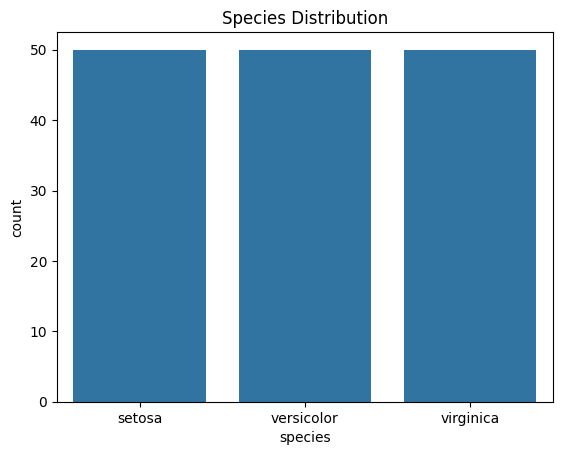

In [12]:
sns.countplot(x='species', data=df)
plt.title("Species Distribution")
plt.show()

#### Sepal Length vs Petal Length

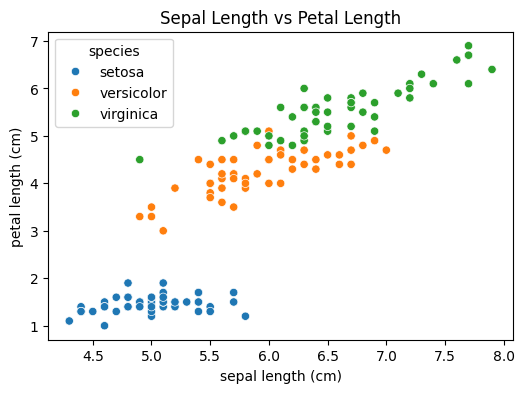

In [13]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x='sepal length (cm)',
    y='petal length (cm)',
    hue='species'
)
plt.title("Sepal Length vs Petal Length")
plt.show()

#### Sepal Width vs Petal Width

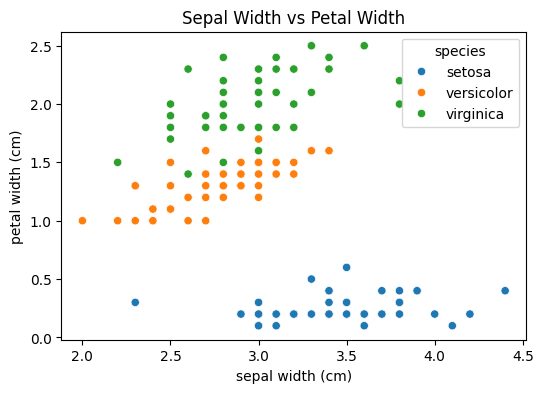

In [14]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x='sepal width (cm)',
    y='petal width (cm)',
    hue='species'
)
plt.title("Sepal Width vs Petal Width")
plt.show()

#### Feature Distribution

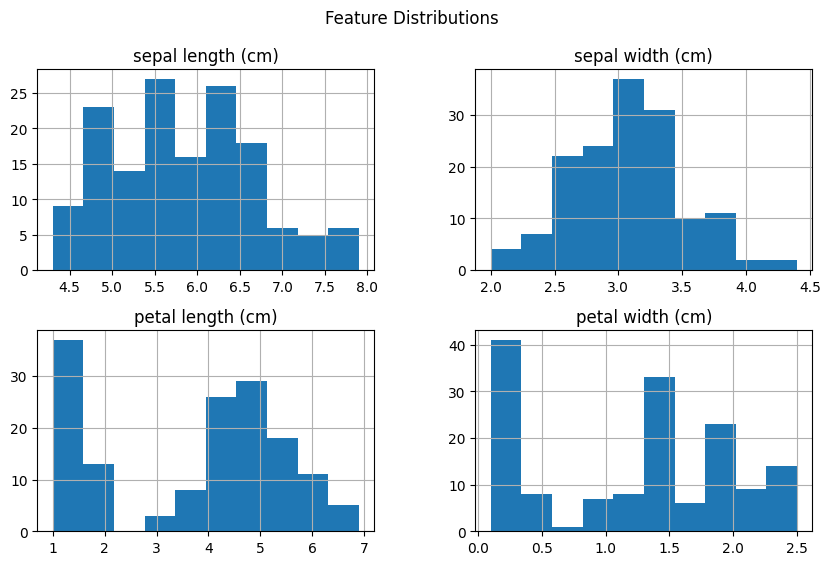

In [15]:
df.drop(['target', 'species'], axis=1).hist(figsize=(10,6))
plt.suptitle("Feature Distributions")
plt.show()

#### Correlation Heatmap

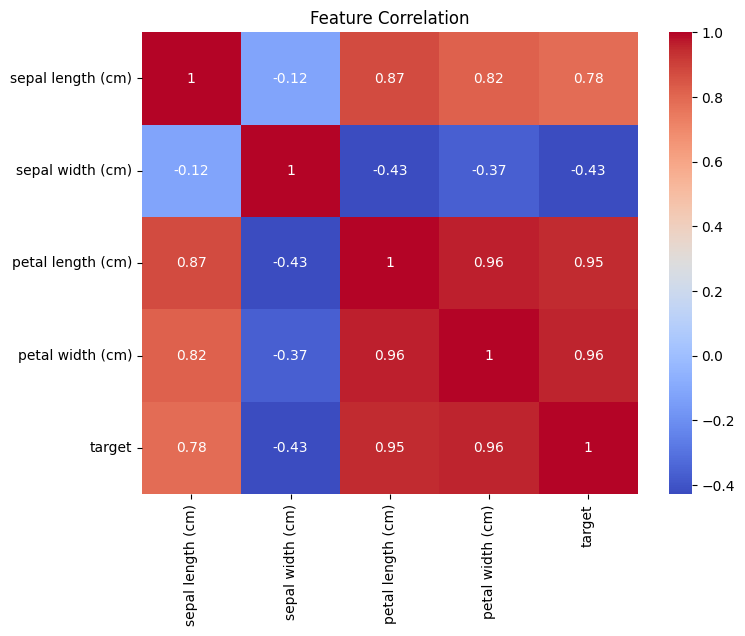

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop(['species'], axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

## 5. Data Preparation

In [17]:
X = df.drop(['target', 'species'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 6. Model Selection

In [18]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss')
}

## 7. Model Training

In [20]:
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully")

Decision Tree trained successfully
Random Forest trained successfully
SVM trained successfully
Logistic Regression trained successfully
Naive Bayes trained successfully
XGBoost trained successfully


## 8. Model Evaluation

In [22]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred, average='weighted')
    ])

#### Results Table

In [24]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score"
])

results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0
2,SVM,1.0,1.0,1.0,1.0
3,Logistic Regression,1.0,1.0,1.0,1.0
4,Naive Bayes,1.0,1.0,1.0,1.0
5,XGBoost,1.0,1.0,1.0,1.0


#### Performance Comparison

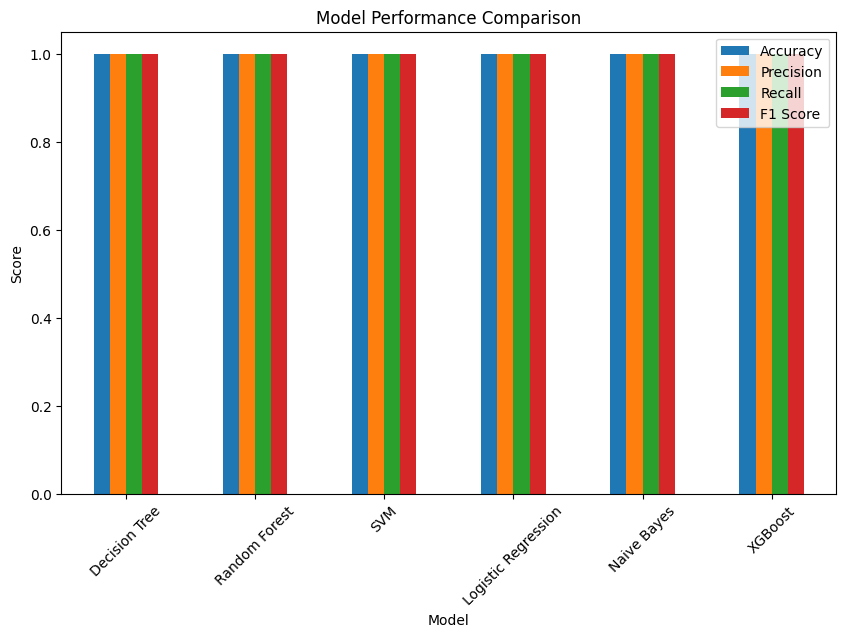

In [25]:
results_df.set_index("Model").plot(kind='bar', figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()